In [25]:
import pickle

class RealTimeRecommender:
    def __init__(self, similarity_map_path):
        """Завантажує словник 1 раз при старті сервера"""
        print(f"Завантаження моделі з {similarity_map_path}...")
        with open(similarity_map_path, 'rb') as f:
            self.sim_map = pickle.load(f)
            
        # Зберігаємо список усіх існуючих аніме в базі для швидкої ініціалізації
        self.all_anime_ids = set(self.sim_map.keys())
        print(f"✅ Готово! В базі {len(self.all_anime_ids)} аніме.")

    def get_recommendations(self, user_profile, top_k=10):
        """
        user_profile: dict, наприклад {123: 1.0, 456: -1.0} (де 123 і 456 - це anime_id)
        top_k: int, скільки рекомендацій повернути
        """
        # 1. Створюємо словник кандидатів, де ВСІ аніме мають бал 0.0 з самого початку
        candidate_scores = {aid: 0.0 for aid in self.all_anime_ids}
        
        # 2. Розрахунок балів (Dynamic Scoring)
        for rated_anime, user_weight in user_profile.items():
            
            # Якщо оціненого аніме немає в нашій базі зв'язків — просто ігноруємо
            if rated_anime not in self.sim_map:
                continue
                
            # Поширюємо вплив
            for similar_anime, sim_score in self.sim_map[rated_anime].items():
                if similar_anime in candidate_scores:
                    candidate_scores[similar_anime] += user_weight * sim_score

        # 3. Відсіювання (Видаляємо ті аніме, які юзер вже оцінив)
        for rated_anime in user_profile.keys():
            # Безпечне видалення (якщо раптом його там не було)
            candidate_scores.pop(rated_anime, None)

        # 4. Сортування та видача
        sorted_candidates = sorted(candidate_scores.items(), key=lambda item: item[1], reverse=True)
        
        return sorted_candidates[:top_k]

In [26]:
import os

# --- ІНІЦІАЛІЗАЦІЯ (Робиться 1 раз при старті додатку) ---
# Вказуємо шлях до вашого реального оптимізованого файлу
output_dir = os.path.join('..', 'data')
#map_path = os.path.join(output_dir, 'svd_similarity_map_optimized.pkl')
map_path = os.path.join(output_dir, 'hybrid_similarity_map.pkl')

# Створюємо ЄДИНИЙ глобальний об'єкт рекомендатора
recommender = RealTimeRecommender(map_path)


# --- ТЕСТУВАННЯ (Імітація API запитів від різних користувачів) ---

# Для тесту візьмемо якісь реальні MAL_ID (наприклад, 20 - Naruto, 1535 - Death Note)
# Замініть ці ID на ті, які точно є у вашому датасеті для перевірки

print("\n--- Запит від Користувача 1 (Фанатик Наруто) ---")
user1_profile = {20: 1.0, 1735: 1.0} # 20 = Naruto, 1735 = Naruto Shippuden
user1_recs = recommender.get_recommendations(user1_profile, top_k=5)

print("Рекомендуємо Користувачу 1:")
for rank, (anime_id, score) in enumerate(user1_recs, 1):
    print(f"{rank}. Anime ID: {anime_id} (Бал: {score:.4f})")


print("\n--- Запит від Користувача 2 (Хейтер) ---")
# Оцінив одне погано, інше добре
user2_profile = {1535: -1.0, 5114: 1.0} # 1535 = Death Note, 5114 = FMA: Brotherhood
user2_recs = recommender.get_recommendations(user2_profile, top_k=5)

print("Рекомендуємо Користувачу 2:")
for rank, (anime_id, score) in enumerate(user2_recs, 1):
    print(f"{rank}. Anime ID: {anime_id} (Бал: {score:.4f})")

Завантаження моделі з ..\data\hybrid_similarity_map.pkl...
✅ Готово! В базі 17179 аніме.

--- Запит від Користувача 1 (Фанатик Наруто) ---
Рекомендуємо Користувачу 1:
1. Anime ID: 269 (Бал: 0.8873)
2. Anime ID: 8246 (Бал: 0.8198)
3. Anime ID: 16870 (Бал: 0.7794)
4. Anime ID: 10589 (Бал: 0.7698)
5. Anime ID: 28755 (Бал: 0.7399)

--- Запит від Користувача 2 (Хейтер) ---
Рекомендуємо Користувачу 2:
1. Anime ID: 2001 (Бал: 0.3640)
2. Anime ID: 2418 (Бал: 0.3325)
3. Anime ID: 37510 (Бал: 0.3281)
4. Anime ID: 19 (Бал: 0.3265)
5. Anime ID: 36766 (Бал: 0.3205)


In [27]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# 1. Завантаження даних
# Припускаємо, що train_final.parquet та test_sampled.parquet вже є у вашій папці
print("Завантаження даних...")
output_dir = os.path.join('..', 'data')
test_sampled = pd.read_parquet(os.path.join(output_dir, 'test_sampled.parquet'))
output_dir = os.path.join(output_dir, 'processed')
train_final = pd.read_parquet(os.path.join(output_dir, 'train_final.parquet'))


unique_users = test_sampled['user_id'].unique()
train_sampled = train_final[train_final['user_id'].isin(unique_users)].copy()

print(f"Відібрано {len(unique_users)} користувачів для тесту.")

# 2. Функції конвертації та метрик
def rating_to_weight(rating):
    """Перетворює 10-бальну оцінку на вагу для алгоритму"""
    if rating >= 8: return 1.0
    #elif rating <= 4: return -1.0
    else: return -1.0

def calculate_ranking_metrics(true_items_ratings, predicted_ranked_items, k=10):
    relevant_items = {iid for iid, rating in true_items_ratings.items() if rating >= 8}
    if not relevant_items: return None 
        
    top_k_pred = predicted_ranked_items[:k]
    hits = len(set(top_k_pred).intersection(relevant_items))
    
    precision = hits / k
    recall = hits / len(relevant_items)
    
    mrr = 0.0
    for rank, item in enumerate(predicted_ranked_items):
        if item in relevant_items:
            mrr = 1.0 / (rank + 1)
            break
            
    y_true = [1 if item in relevant_items else 0 for item in predicted_ranked_items]
    y_scores = list(range(len(predicted_ranked_items), 0, -1)) 
    try: auc = roc_auc_score(y_true, y_scores)
    except: auc = np.nan
        
    return {'Precision@10': precision, 'Recall@10': recall, 'MRR': mrr, 'AUC': auc}

# 3. Головний цикл тестування
results_list = []
# recommender - це ваш об'єкт класу RealTimeRecommender, створений раніше

for user_id in tqdm(unique_users, desc="Тестування In-Memory моделі"):
    
    # Дані тесту (майбутнє)
    user_test = test_sampled[test_sampled['user_id'] == user_id]
    true_ratings = dict(zip(user_test['anime_id'], user_test['rating']))
    
    if not any(r >= 8 for r in true_ratings.values()):
        continue
        
    train_count = user_test['train_count'].iloc[0]
    
    # Дані тренування (історія)
    user_train = train_sampled[train_sampled['user_id'] == user_id]
    
    # Формуємо профіль користувача: {anime_id: weight}
    user_profile = {
        row['anime_id']: rating_to_weight(row['rating']) 
        for _, row in user_train.iterrows()
    }
    
    # Отримуємо рекомендації. 
    # Важливо: просимо видати ВСІ аніме (len(all_anime_ids)), щоб AUC порахувався коректно
    recs = recommender.get_recommendations(user_profile, top_k=len(recommender.all_anime_ids))
    
    # Витягуємо тільки ідентифікатори аніме по порядку спадання балу
    ranked_items = [aid for aid, score in recs]
    
    # Рахуємо метрики
    metrics = calculate_ranking_metrics(true_ratings, ranked_items, k=10)
    
    if metrics:
        metrics['user_id'] = user_id
        metrics['train_count'] = train_count
        results_list.append(metrics)

# Зберігаємо результати у DataFrame
rt_metrics_df = pd.DataFrame(results_list)
print("\n✅ Розрахунок завершено! Середні метрики:")
print(rt_metrics_df[['Precision@10', 'Recall@10', 'MRR', 'AUC']].mean())

Завантаження даних...
Відібрано 1590 користувачів для тесту.


Тестування In-Memory моделі: 100%|██████████| 1590/1590 [01:13<00:00, 21.64it/s]


✅ Розрахунок завершено! Середні метрики:
Precision@10    0.367927
Recall@10       0.076265
MRR             0.666102
AUC             0.705095
dtype: float64


In [29]:
rt_metrics_df.to_parquet(os.path.join('..', 'data', 'rt_metrics_df.parquet'), index=False)

In [39]:
import networkx as nx
import numpy as np
import pandas as pd
import os

print("Завантаження метаданих аніме...")

output_dir = os.path.join('..', 'data', 'processed')  # Вказуємо правильний шлях до вашого output_dir
# 1. Завантажуємо anime_clean (переконайтеся, що output_dir визначено)
anime_clean = pd.read_parquet(os.path.join(output_dir, "anime_clean.parquet"))

print("--- Крок 1: Побудова графа та Кластеризація (Метод Лувена) ---")

# 1. Створюємо порожній неорієнтований граф
G = nx.Graph()

# 2. Наповнюємо граф ребрами з вашого словника
for source, neighbors in recommender.sim_map.items():
    for target, weight in neighbors.items():
        # Для кластеризації спільнот беремо тільки позитивні зв'язки (схожість)
        # Якщо використовуєте SVD-словник, негативні зв'язки означають "антиподи", їх ми для кластерів ігноруємо
        if weight > 0:  # Ви можете налаштувати цей поріг для більш щільних або розріджених кластерів
            G.add_edge(source, target, weight=weight)

# 3. Запускаємо Метод Лувена (вбудований у сучасний NetworkX)
# Він поверне список множин (sets), де кожна множина - це кластер (спільнота)
communities = list(nx.community.louvain_communities(G, weight='weight'))

print(f"✅ Граф успішно розбито на {len(communities)} унікальних кластерів!")

print("\n--- Крок 2: Сортування та підготовка Round-Robin черги ---")

# Створюємо словник популярності (Показник Popularity: 1 - найпопулярніше, чим більше, тим гірше)
# Переконайтеся, що колонка називається 'popularity'. Якщо її немає, можна використати 'members', але тоді сортувати треба у зворотному порядку (reverse=True)
pop_dict = dict(zip(anime_clean['MAL_ID'], anime_clean['Popularity']))

# 1. Готуємо списки для кожного кластера
clusters_sorted = []

for comm in communities:
    # Залишаємо тільки ті аніме, про які є інфа в anime_clean
    valid_nodes = [node for node in comm if node in pop_dict]
    
    # Сортуємо аніме всередині кластера ЗА ЗРОСТАННЯМ Popularity (1, 2, 3...)
    sorted_nodes = sorted(valid_nodes, key=lambda x: pop_dict[x])
    
    if sorted_nodes:
        clusters_sorted.append(sorted_nodes)

# 2. Сортуємо самі кластери за кількістю аніме в них (від найбільшого до найменшого)
clusters_sorted.sort(key=len, reverse=True)

print(f"Розміри кластерів: {[len(c) for c in clusters_sorted]}")

print("\n--- Крок 3: Формування глобальної черги (Round-Robin) ---")

active_learning_queue = []

# Поки хоча б в одному кластері є елементи - продовжуємо цикл
while any(clusters_sorted):
    for cluster in clusters_sorted:
        if cluster: # Якщо кластер ще не порожній
            # Забираємо ПЕРШИЙ елемент (найпопулярніше аніме цього кластера) і додаємо в чергу
            active_learning_queue.append(cluster.pop(0))

print(f"✅ Ідеальна черга сформована! Всього вузлів: {len(active_learning_queue)}")

# --- Вивід перших 10 аніме з черги для перевірки ---
top_10_hub_ids = active_learning_queue[:10]
top_10_anime = anime_clean[anime_clean['MAL_ID'].isin(top_10_hub_ids)].copy()

# Зберігаємо правильний порядок
top_10_anime['MAL_ID'] = pd.Categorical(top_10_anime['MAL_ID'], categories=top_10_hub_ids, ordered=True)
top_10_anime = top_10_anime.sort_values('MAL_ID')

# Показуємо результат
columns_to_show = ['MAL_ID', 'Name', 'Score', 'Genres', 'Popularity', 'Members']
existing_cols = [col for col in columns_to_show if col in top_10_anime.columns]

print(f"\n--- СПРАВЖНІ ТОП-10 ДЛЯ ОНБОРДИНГУ (З різних кластерів) ---")
display(top_10_anime[existing_cols].reset_index(drop=True))

Завантаження метаданих аніме...
--- Крок 1: Побудова графа та Кластеризація (Метод Лувена) ---
✅ Граф успішно розбито на 7 унікальних кластерів!

--- Крок 2: Сортування та підготовка Round-Robin черги ---
Розміри кластерів: [9701, 3554, 1839, 1373, 344, 308, 60]

--- Крок 3: Формування глобальної черги (Round-Robin) ---
✅ Ідеальна черга сформована! Всього вузлів: 17179

--- СПРАВЖНІ ТОП-10 ДЛЯ ОНБОРДИНГУ (З різних кластерів) ---


,MAL_ID,Name,Score,Genres,Popularity,Members
0,1535,Death Note,8.63,"Mystery, Police, Psychological, Supernatural, ...",1,2589552
1,47,Akira,8.17,"Action, Military, Sci-Fi, Adventure, Horror, S...",197,566538
2,21039,Gatchaman Crowds Insight,7.30,"Adventure, Sci-Fi",1923,63861
3,1293,Urusei Yatsura,7.69,"Action, Sci-Fi, Adventure, Comedy, Drama, Romance",2056,57537
4,20583,Haikyuu!!,8.53,"Comedy, Sports, Drama, School, Shounen",50,1185274
5,39166,Girls & Panzer: Saishuushou Part 3,NaN,"Military, School",5214,8637
6,235,Detective Conan,8.16,"Adventure, Mystery, Comedy, Police, Shounen",580,252940
7,16498,Shingeki no Kyojin,8.48,"Action, Military, Mystery, Super Power, Drama,...",2,2531397
8,339,Serial Experiments Lain,8.03,"Dementia, Drama, Mystery, Psychological, Sci-F...",255,480696
9,35015,Ani ni Tsukeru Kusuri wa Nai!,7.46,"Slice of Life, Comedy, School",1990,60586


In [ ]:
#act_learn_queue = active_learning_queue.copy()

In [20]:
act_learn_queue

[1535,
 1,
 35015,
 1293,
 918,
 39166,
 235,
 30,
 16498,
 205,
 6758,
 368,
 28977,
 39167,
 1365,
 32,
 5114,
 457,
 40934,
 10851,
 9969,
 39168,
 8310,
 2759,
 11757,
 19,
 37924,
 10779,
 40776,
 39169,
 779,
 3784,
 30276,
 227,
 32212,
 6893,
 15417,
 41919,
 781,
 3785,
 31964,
 47,
 37599,
 22429,
 34096,
 45055,
 1364,
 31,
 22319,
 1210,
 36267,
 29575,
 18689,
 41361,
 780,
 38055,
 20,
 790,
 31157,
 7411,
 15335,
 12591,
 1363,
 9253,
 339,
 35988,
 8918,
 10218,
 38164,
 5460,
 19815,
 43,
 39959,
 10380,
 12115,
 30943,
 1367,
 32281,
 33,
 40807,
 27969,
 12113,
 39227,
 6467,
 11061,
 437,
 890,
 11879,
 35843,
 31150,
 1506,
 33486,
 1943,
 34550,
 2432,
 36838,
 26117,
 1366,
 6547,
 7785,
 40136,
 11827,
 7472,
 33882,
 1505,
 1575,
 323,
 31631,
 24641,
 37491,
 23031,
 4447,
 25777,
 5,
 40372,
 4473,
 30230,
 30939,
 9963,
 4224,
 202,
 8098,
 25345,
 37932,
 13457,
 2171,
 1735,
 22135,
 10999,
 812,
 32366,
 32773,
 12117,
 20507,
 3002,
 37031,
 32587,
 2975

In [36]:
# --- Вивід перших 10 аніме з черги для перевірки ---
top_10_hub_ids = act_learn_queue[:10]
top_10_anime = anime_clean[anime_clean['MAL_ID'].isin(top_10_hub_ids)].copy()

# Зберігаємо правильний порядок
top_10_anime['MAL_ID'] = pd.Categorical(top_10_anime['MAL_ID'], categories=top_10_hub_ids, ordered=True)
top_10_anime = top_10_anime.sort_values('MAL_ID')

# Показуємо результат
columns_to_show = ['MAL_ID', 'Name', 'Score', 'Genres', 'Popularity', 'Members']
existing_cols = [col for col in columns_to_show if col in top_10_anime.columns]

print(f"\n--- СПРАВЖНІ ТОП-10 ДЛЯ ОНБОРДИНГУ (З різних кластерів) ---")
display(top_10_anime[existing_cols].reset_index(drop=True))


--- СПРАВЖНІ ТОП-10 ДЛЯ ОНБОРДИНГУ (З різних кластерів) ---


,MAL_ID,Name,Score,Genres,Popularity,Members
0,1535,Death Note,8.63,"Mystery, Police, Psychological, Supernatural, ...",1,2589552
1,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",39,1251960
2,35015,Ani ni Tsukeru Kusuri wa Nai!,7.46,"Slice of Life, Comedy, School",1990,60586
3,1293,Urusei Yatsura,7.69,"Action, Sci-Fi, Adventure, Comedy, Drama, Romance",2056,57537
4,918,Gintama,8.96,"Action, Comedy, Historical, Parody, Samurai, S...",114,754607
5,39166,Girls & Panzer: Saishuushou Part 3,NaN,"Military, School",5214,8637
6,235,Detective Conan,8.16,"Adventure, Mystery, Comedy, Police, Shounen",580,252940
7,30,Neon Genesis Evangelion,8.32,"Action, Sci-Fi, Dementia, Psychological, Drama...",54,1160651
8,16498,Shingeki no Kyojin,8.48,"Action, Military, Mystery, Super Power, Drama,...",2,2531397
9,205,Samurai Champloo,8.50,"Action, Adventure, Comedy, Historical, Samurai...",86,892196


Підготовка даних для In-Memory моделі...


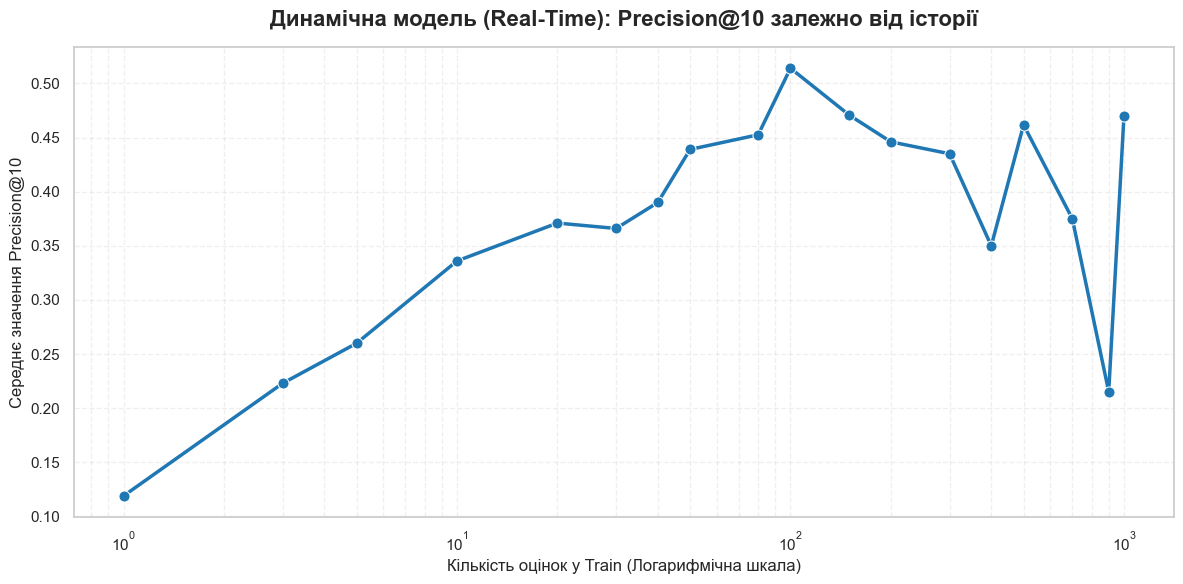

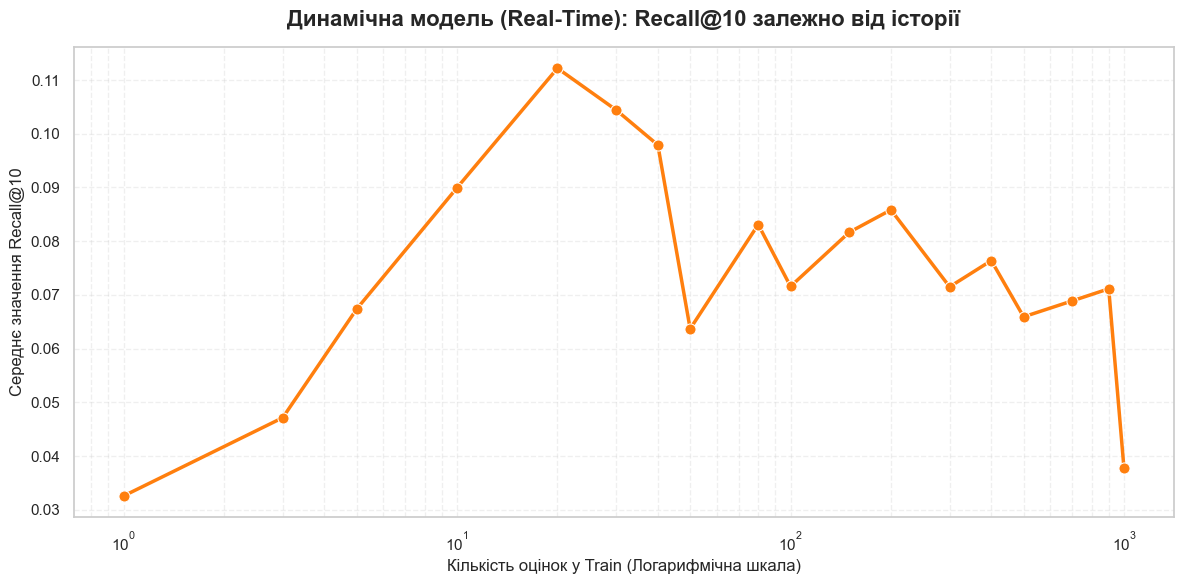

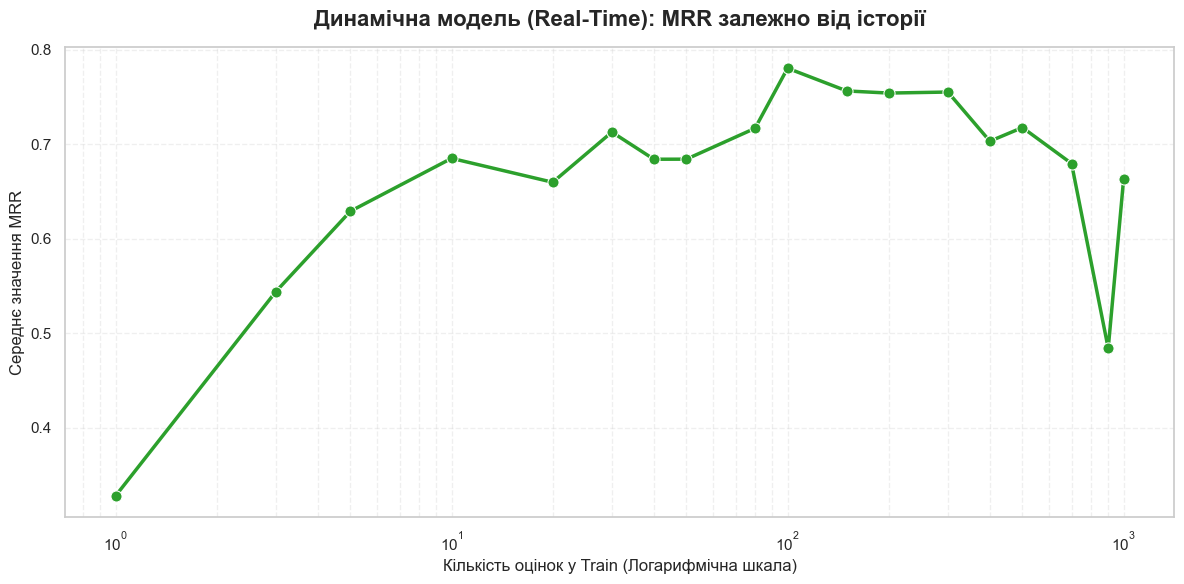

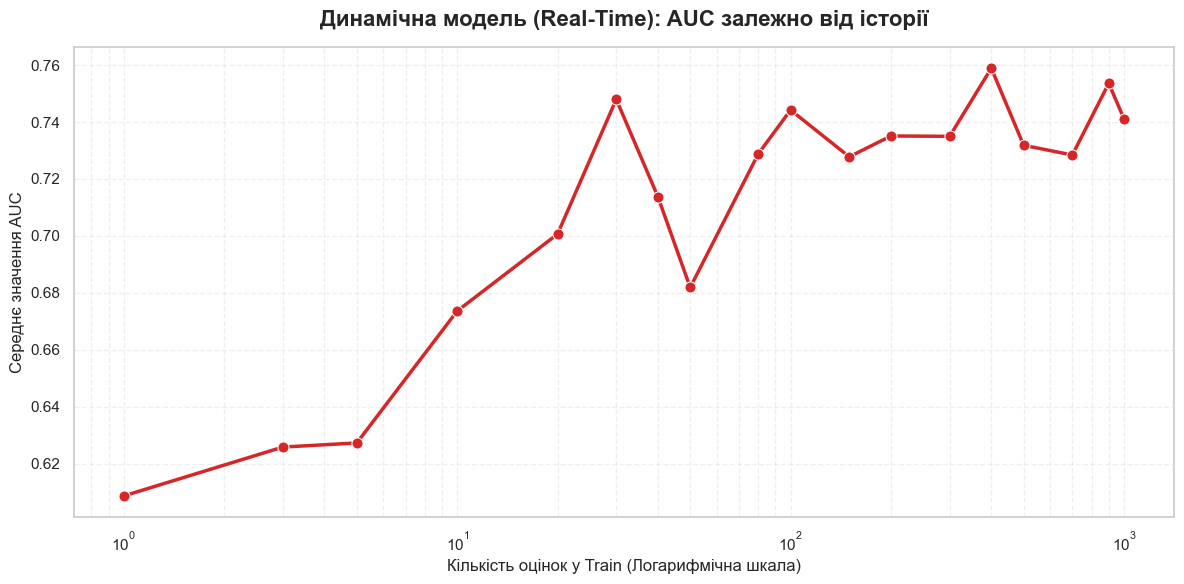

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Підготовка даних для In-Memory моделі...")

# Відбираємо наші референсні точки для осі X
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

# Фільтруємо датафрейм (передбачається, що rt_metrics_df у вас вже є в пам'яті)
df_filtered = rt_metrics_df[rt_metrics_df['train_count'].isin(ref_counts)].copy()

# Групуємо і знаходимо середнє значення кожної метрики для кожної точки
trend_data = df_filtered.groupby('train_count').mean().reset_index()

metrics_to_plot = ['Precision@10', 'Recall@10', 'MRR', 'AUC']
# Задаємо окремий колір для графіка кожної метрики
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

# Будуємо 4 окремі графіки
for i, metric in enumerate(metrics_to_plot):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=trend_data, 
        x='train_count', 
        y=metric, 
        marker='o',       # Додаємо точки
        linewidth=2.5,
        color=colors[i],
        markersize=8
    )
    
    # Налаштування осей
    plt.xscale('log')
    plt.title(f'Динамічна модель (Real-Time): {metric} залежно від історії', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Кількість оцінок у Train (Логарифмічна шкала)', fontsize=12)
    plt.ylabel(f'Середнє значення {metric}', fontsize=12)
    
    plt.grid(True, which="both", alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80 + "\n")

In [40]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# 1. Завантаження даних
# Припускаємо, що train_final.parquet та test_sampled.parquet вже є у вашій папці
print("Завантаження даних...")
output_dir = os.path.join('..', 'data')
test_sampled = pd.read_parquet(os.path.join(output_dir, 'test_sampled.parquet'))
output_dir = os.path.join(output_dir, 'processed')
train_final = pd.read_parquet(os.path.join(output_dir, 'train_final.parquet'))


unique_users = test_sampled['user_id'].unique()
train_sampled = train_final[train_final['user_id'].isin(unique_users)].copy()

print(f"Відібрано {len(unique_users)} користувачів для тесту.")

# 2. Функції конвертації та метрик
def rating_to_weight(rating):
    """Перетворює 10-бальну оцінку на вагу для алгоритму"""
    if rating >= 8: return 1.0
    #elif rating <= 4: return -1.0
    else: return -1.0

def calculate_ranking_metrics(true_items_ratings, predicted_ranked_items, k=10):
    relevant_items = {iid for iid, rating in true_items_ratings.items() if rating >= 8}
    if not relevant_items: return None 
        
    top_k_pred = predicted_ranked_items[:k]
    hits = len(set(top_k_pred).intersection(relevant_items))
    
    precision = hits / k
    recall = hits / len(relevant_items)
    
    mrr = 0.0
    for rank, item in enumerate(predicted_ranked_items):
        if item in relevant_items:
            mrr = 1.0 / (rank + 1)
            break
            
    y_true = [1 if item in relevant_items else 0 for item in predicted_ranked_items]
    y_scores = list(range(len(predicted_ranked_items), 0, -1)) 
    try: auc = roc_auc_score(y_true, y_scores)
    except: auc = np.nan
        
    return {'Precision@10': precision, 'Recall@10': recall, 'MRR': mrr, 'AUC': auc}

ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

print("Крок 1: Підготовка єдиного датасету оцінок...")



# Поєднуємо train та test для отримання повної картини по кожному юзеру
df_train = train_sampled[['user_id', 'anime_id', 'rating']]
df_test = test_sampled[['user_id', 'anime_id', 'rating']]
all_ratings_df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Загальна кількість оцінок для тесту: {len(all_ratings_df)}")

# Змінна для збереження результатів
al_results_list = []

print("Крок 2: Симуляція процесу Onboarding для кожного користувача...")

# Проходимось по кожному користувачу
for user_id in tqdm(unique_users, desc="Тестування Active Learning Queue"):
    
    # Витягуємо всі оцінки цього користувача як словник {anime_id: rating}
    user_data = all_ratings_df[all_ratings_df['user_id'] == user_id]
    user_all_ratings = dict(zip(user_data['anime_id'], user_data['rating']))
    
    # Симулюємо різну глибину опитування (скільки тайтлів з черги ми йому показали)
    for ask_count in ref_counts:
        
        # Беремо перші ask_count аніме з нашої ідеальної черги
        asked_items = set(active_learning_queue[:ask_count])
        
        # Формуємо профіль: беремо ТІЛЬКИ ті аніме з питань, які юзер реально оцінив
        user_profile = {}
        for aid in asked_items:
            if aid in user_all_ratings:
                user_profile[aid] = rating_to_weight(user_all_ratings[aid])
                
        # Залишок історії користувача (Ground Truth - те, що ми маємо вгадати)
        # Виключаємо ті тайтли, про які ми щойно запитали
        true_future_ratings = {
            aid: rating for aid, rating in user_all_ratings.items() 
            if aid not in asked_items
        }
        
        # Якщо в залишку немає оцінок >= 8, ми не зможемо порахувати Precision/Recall
        if not any(r >= 8 for r in true_future_ratings.values()):
            continue
            
        # Якщо профіль порожній (користувач не бачив жодного аніме з asked_items),
        # функція поверне базові рекомендації. Ми все одно це тестуємо!
        
        # Отримуємо рекомендації від In-Memory алгоритму
        recs = recommender.get_recommendations(user_profile, top_k=len(recommender.all_anime_ids))
        ranked_items = [aid for aid, score in recs]
        
        # Рахуємо метрики нашою існуючою функцією
        metrics = calculate_ranking_metrics(true_future_ratings, ranked_items, k=10)
        
        if metrics:
            metrics['user_id'] = user_id
            metrics['asked_count'] = ask_count # Скільки аніме ми ПОКАЗАЛИ
            metrics['profile_size'] = len(user_profile) # Скільки він РЕАЛЬНО оцінив
            al_results_list.append(metrics)

# Крок 3: Збереження у DataFrame
metrics_df = pd.DataFrame(al_results_list)

print("\n✅ Симуляцію завершено! Базові статистики:")
print(f"Згенеровано {len(metrics_df)} рядків з метриками.")
print(metrics_df[['Precision@10', 'Recall@10', 'MRR', 'AUC']].mean())

Завантаження даних...
Відібрано 1590 користувачів для тесту.
Крок 1: Підготовка єдиного датасету оцінок...
Загальна кількість оцінок для тесту: 586517
Крок 2: Симуляція процесу Onboarding для кожного користувача...


Тестування Active Learning Queue: 100%|██████████| 1590/1590 [11:27<00:00,  2.31it/s]


✅ Симуляцію завершено! Базові статистики:
Згенеровано 28595 рядків з метриками.
Precision@10    0.269065
Recall@10       0.028632
MRR             0.498793
AUC             0.638161
dtype: float64


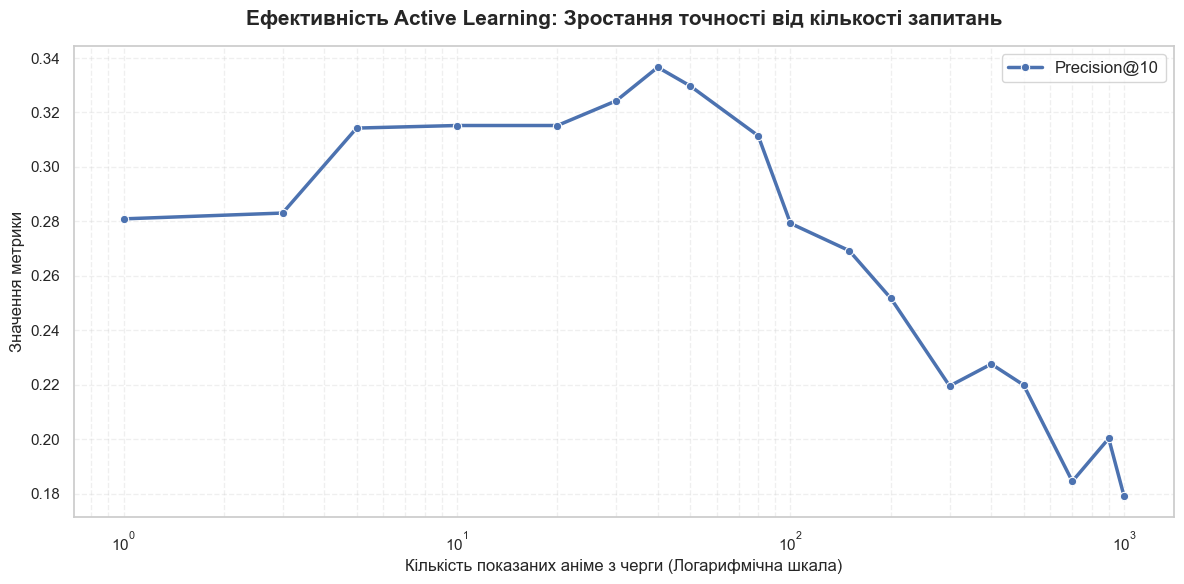


Конверсія відповідей (Показали -> Реально оцінив):
   asked_count  profile_size
0            1          0.69
1            3          1.03
2            5          1.39
3           10          2.34
4           20          3.56
5           30          5.40
6           40          6.46
7           50          7.84
8           80         10.96
9          100         13.36


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Рахуємо середні метрики для кожної кількості заданих запитань (asked_count)
trend_al = metrics_df.groupby('asked_count').mean().reset_index()

plt.figure(figsize=(12, 6))

# Будуємо графік Precision та MRR (найважливіші для онбордингу)
sns.lineplot(data=trend_al, x='asked_count', y='Precision@10', marker='o', label='Precision@10', linewidth=2.5)
#sns.lineplot(data=trend_al, x='asked_count', y='MRR', marker='s', label='MRR', linewidth=2.5)

plt.xscale('log')
plt.title('Ефективність Active Learning: Зростання точності від кількості запитань', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Кількість показаних аніме з черги (Логарифмічна шкала)', fontsize=12)
plt.ylabel('Значення метрики', fontsize=12)
plt.grid(True, which="both", alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Можемо також подивитись, скільки реально оцінок отримує система на кожному етапі
print("\nКонверсія відповідей (Показали -> Реально оцінив):")
print(trend_al[['asked_count', 'profile_size']].head(10).round(2))

Підготовка даних для In-Memory моделі...


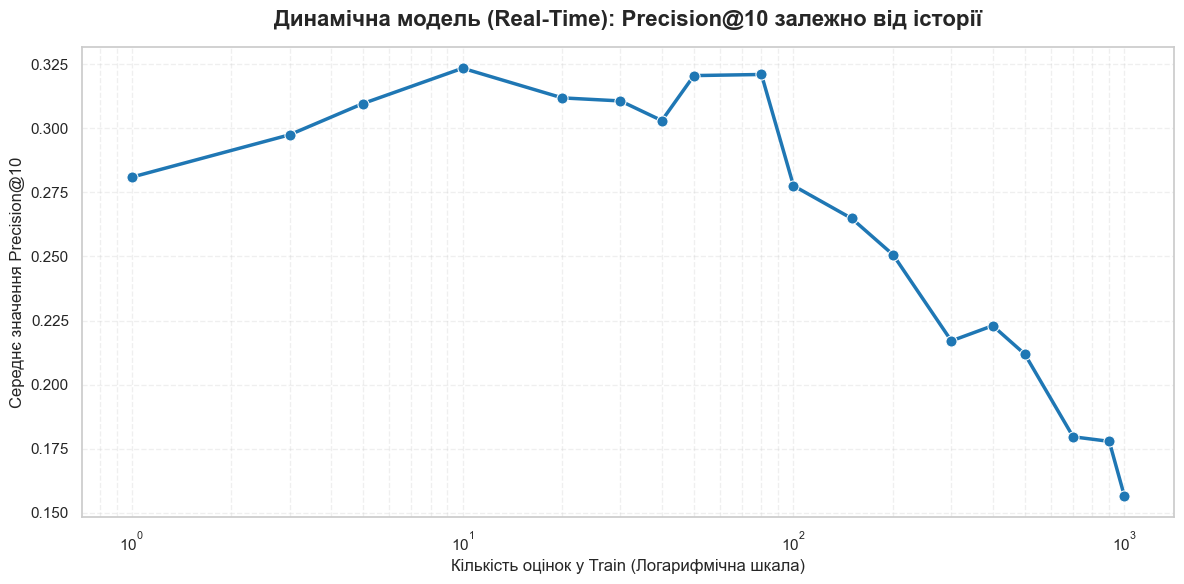

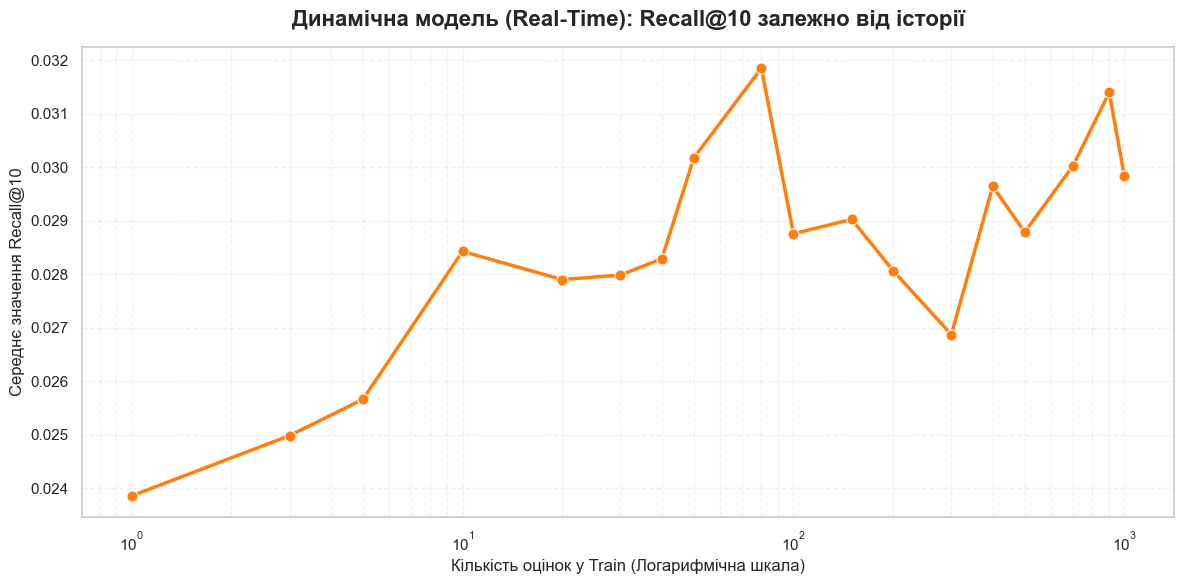

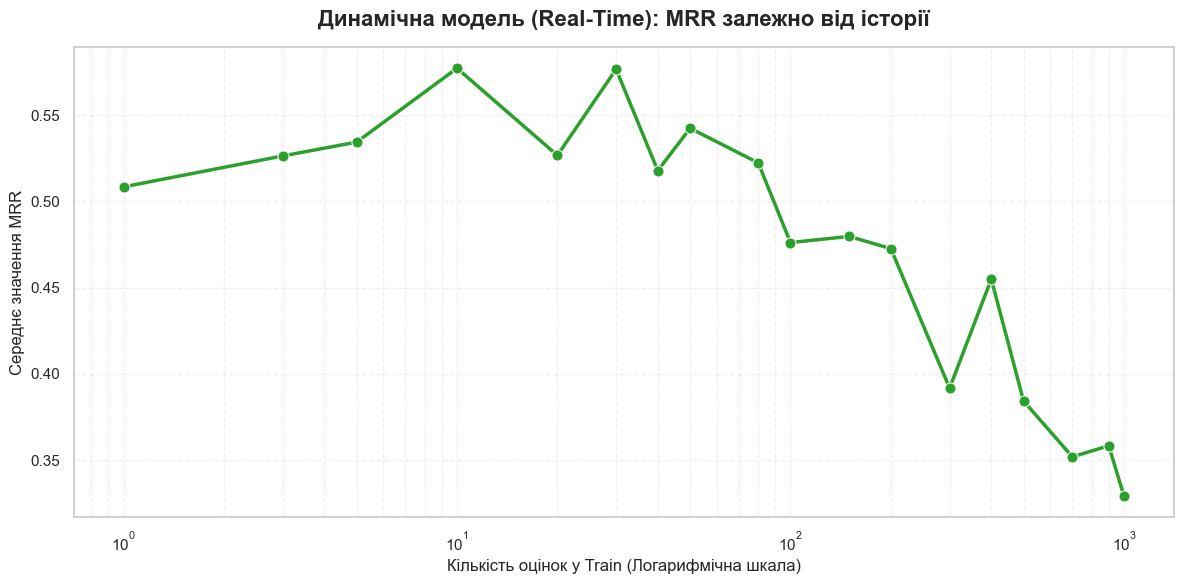

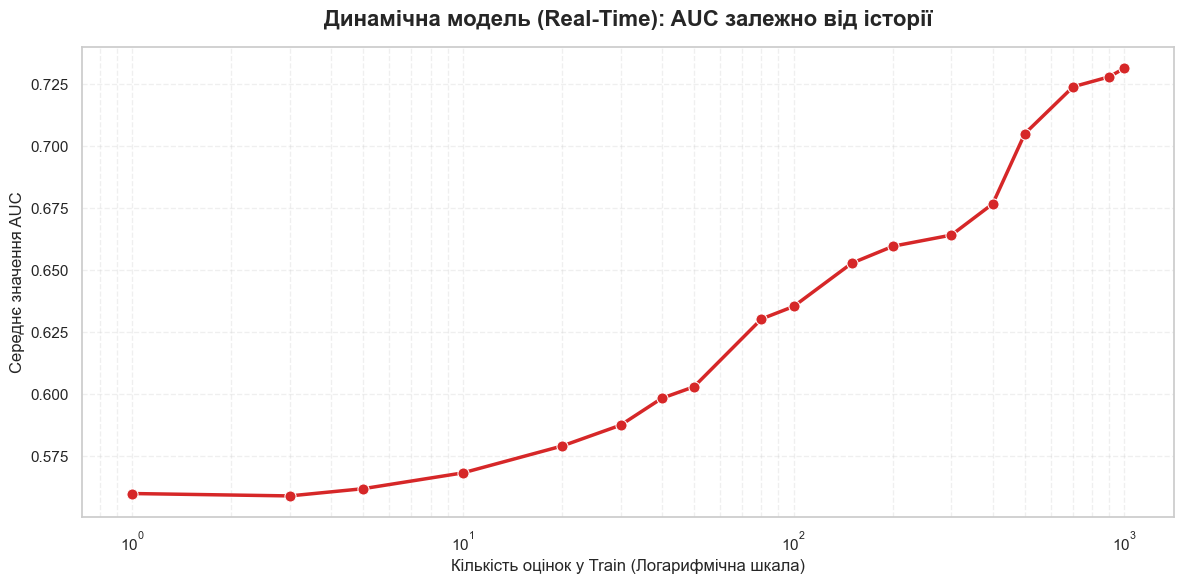

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Підготовка даних для In-Memory моделі...")

# Фільтруємо датафрейм (передбачається, що metrics_df у вас вже є в пам'яті)
df_filtered = metrics_df[metrics_df['asked_count'].isin(ref_counts)].copy()

# Групуємо і знаходимо середнє значення кожної метрики для кожної точки
trend_data = df_filtered.groupby('asked_count').mean().reset_index()

metrics_to_plot = ['Precision@10', 'Recall@10', 'MRR', 'AUC']
# Задаємо окремий колір для графіка кожної метрики
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

# Будуємо 4 окремі графіки
for i, metric in enumerate(metrics_to_plot):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=trend_data, 
        x='asked_count', 
        y=metric, 
        marker='o',       # Додаємо точки
        linewidth=2.5,
        color=colors[i],
        markersize=8
    )
    
    # Налаштування осей
    plt.xscale('log')
    plt.title(f'Динамічна модель (Real-Time): {metric} залежно від історії', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Кількість оцінок у Train (Логарифмічна шкала)', fontsize=12)
    plt.ylabel(f'Середнє значення {metric}', fontsize=12)
    
    plt.grid(True, which="both", alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80 + "\n")

In [19]:
output_dir = os.path.join('..', 'data', 'processed')
metrics_df.to_parquet(os.path.join(output_dir, 'active_learning_metrics.parquet'), index=False)
print(f"✅ Результати збережено у {os.path.join(output_dir, 'active_learning_metrics.parquet')}")

✅ Результати збережено у ..\data\processed\active_learning_metrics.parquet


In [21]:
import pickle
output_dir = os.path.join('..', 'data')
with open(os.path.join(output_dir, 'active_learning_queue.pkl'), 'wb') as f:
    pickle.dump(active_learning_queue, f)